# Temporary Explorative Data Analyse

## Charger les données


In [98]:
import pandas as pd
import numpy as np
import glob

In [99]:
df_linkedin = pd.read_excel('scraping_results/result_linkedin.com.xlsx')
df_linkedin.head()

,config_name,domain,country,currency,date,brand,start_url,start_url_formatted,url,entreprise,poste,description,date_de_publication,nb_candidats,location
0,linkedin.com,linkedin.com,France,EUR,2026-04-27,consultantia,https://www.linkedin.com/jobs/search/?currentJ...,https://www.linkedin.com/jobs/search/?currentJ...,https://www.linkedin.com/jobs/view/4386503400/...,RSM France,Consultant Senior Data & IA H/F (75),Rejoignez RSM et participez à une aventure hum...,Republication il y a 2 semaines,26 personnes ont cliqué sur Postuler,"Paris, Île-de-France, France"
1,linkedin.com,linkedin.com,France,EUR,2026-04-27,consultantia,https://www.linkedin.com/jobs/search/?currentJ...,https://www.linkedin.com/jobs/search/?currentJ...,https://www.linkedin.com/jobs/view/4390938905/...,Capgemini Invent Giulia Arca,Consultante expérimentée / Consultant expérime...,Consultante expérimentée / Consultant expérime...,Republication il y a 2 semaines,64 candidats,"Issy-les-Moulineaux, Île-de-France, France"
2,linkedin.com,linkedin.com,France,EUR,2026-04-27,consultantia,https://www.linkedin.com/jobs/search/?currentJ...,https://www.linkedin.com/jobs/search/?currentJ...,https://www.linkedin.com/jobs/view/4392431203/...,GEC _ Global Experts Consulting,Consultant ServiceNow Technico-Fonctionnel – I...,Dans le cadre du déploiement de cas d’usage d’...,il y a 3 semaines,14 candidats,"Paris, Île-de-France, France"
3,linkedin.com,linkedin.com,France,EUR,2026-04-27,consultantia,https://www.linkedin.com/jobs/search/?currentJ...,https://www.linkedin.com/jobs/search/?currentJ...,https://www.linkedin.com/jobs/view/4389275158/...,Talan,Consulting - Consultant Confirmé / Senior – St...,"Description de l'entreprise Fondé en France, T...",il y a 1 mois,4 personnes ont cliqué sur Postuler,"Paris, Île-de-France, France"
4,linkedin.com,linkedin.com,France,EUR,2026-04-27,consultantia,https://www.linkedin.com/jobs/search/?currentJ...,https://www.linkedin.com/jobs/search/?currentJ...,https://www.linkedin.com/jobs/view/4402502434/...,Sia,Consultant(e) Senior Data Science & IA,Sia est un groupe international de conseil en ...,il y a 1 semaine,19 candidats,"Paris, Île-de-France, France"


In [100]:
fichiers_xlsx = glob.glob("scraping_results/*.xlsx")

liste_dataframes = []


for fichier in fichiers_xlsx:
  df_temp = pd.read_excel(fichier)
  
  df_temp = df_temp.rename(columns={'profil_recherche':'experience', 'brand': 'poste_recherche'})

  liste_dataframes.append(df_temp)
  
df_global = pd.concat(liste_dataframes, ignore_index=True)

# Dropping useless data columns
df_global = df_global.drop(columns = ["config_name","currency",
                                      "start_url","start_url_formatted",
                                      "country", "poste_recherche"])

df_global["date"] = pd.to_datetime(df_global["date"]).dt.strftime("%Y-%m")

before = len(df_global)
df_global = df_global.drop_duplicates()
print("Nombre de doublons supprimé : ", before - len(df_global))

df_global.head()

Nombre de doublons supprimé :  0


,domain,date,url,entreprise,poste,description,date_de_publication,nb_candidats,location,experience
0,linkedin.com,2026-04,https://www.linkedin.com/jobs/view/4386503400/...,RSM France,Consultant Senior Data & IA H/F (75),Rejoignez RSM et participez à une aventure hum...,Republication il y a 2 semaines,26 personnes ont cliqué sur Postuler,"Paris, Île-de-France, France",NaN
1,linkedin.com,2026-04,https://www.linkedin.com/jobs/view/4390938905/...,Capgemini Invent Giulia Arca,Consultante expérimentée / Consultant expérime...,Consultante expérimentée / Consultant expérime...,Republication il y a 2 semaines,64 candidats,"Issy-les-Moulineaux, Île-de-France, France",NaN
2,linkedin.com,2026-04,https://www.linkedin.com/jobs/view/4392431203/...,GEC _ Global Experts Consulting,Consultant ServiceNow Technico-Fonctionnel – I...,Dans le cadre du déploiement de cas d’usage d’...,il y a 3 semaines,14 candidats,"Paris, Île-de-France, France",NaN
3,linkedin.com,2026-04,https://www.linkedin.com/jobs/view/4389275158/...,Talan,Consulting - Consultant Confirmé / Senior – St...,"Description de l'entreprise Fondé en France, T...",il y a 1 mois,4 personnes ont cliqué sur Postuler,"Paris, Île-de-France, France",NaN
4,linkedin.com,2026-04,https://www.linkedin.com/jobs/view/4402502434/...,Sia,Consultant(e) Senior Data Science & IA,Sia est un groupe international de conseil en ...,il y a 1 semaine,19 candidats,"Paris, Île-de-France, France",NaN


In [101]:
df = df_global.copy()

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2472 entries, 0 to 2471
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   domain               2472 non-null   str  
 1   date                 2472 non-null   str  
 2   url                  2469 non-null   str  
 3   entreprise           2175 non-null   str  
 4   poste                2457 non-null   str  
 5   description          2455 non-null   str  
 6   date_de_publication  1317 non-null   str  
 7   nb_candidats         792 non-null    str  
 8   location             2343 non-null   str  
 9   experience           729 non-null    str  
dtypes: str(10)
memory usage: 193.3 KB


In [102]:
df.value_counts('domain')

domain
linkedin.com                 1105
fr.indeed.com                 564
candidat.francetravail.fr     376
hellowork.com                 345
jobs.stationf.co               82
Name: count, dtype: int64

In [103]:
df.iloc[0]["description"]

"Rejoignez RSM et participez à une aventure humaine et entrepreneuriale ! Mission RSM est devenu 6ème réseau mondial en Audit, Expertise Comptable et Conseil grâce à l’engagement de nos équipes. Dans notre bureau de Paris, plus de 600 expert∙e∙s évoluent au quotidien dans un environnement bienveillant et en constante évolution, où autonomie et prise d’initiatives sont valorisées. « Lors de mon arrivée, ce qui m’a tout de suite plu c’est la relation humaine et la proximité avec les associés. Les équipes grandissent, pour autant la gestion reste à taille humaine. » Antoine « Chez RSM toutes les conditions sont réunies pour progresser et aller de l’avant, c’est vraiment une très bonne école de formation. » Richard Chez RSM, chaque jour est une opportunité de grandir. Nous avons à cœur de faire évoluer nos collaborateur∙trice∙s tout en accompagnant nos clients avec excellence. Ainsi, 95% des collaborateurs nous recommandent. Si vous êtes passionné∙e, ambitieux∙se et prêt∙e à rejoindre une 

In [104]:
# Get indexes where experience is not null
exp_indices = df[df["experience"].notna()].index

exp_indices = np.random.permutation(exp_indices)

print(f"Offers with experience field extracted : {len(exp_indices)}")

Offers with experience field extracted : 729


In [105]:
counts = df["poste"].value_counts()

counts.to_csv('titre_des_postes.csv')

In [106]:
print(f'Il y a {len(counts)} titre de poste unique')

Il y a 1676 titre de poste unique


In [107]:
import re, unicodedata
import pandas as pd

def norm(s):
    # NFKD : retire les accents et convertit les caractères "gras" Unicode
    s = unicodedata.normalize("NFKD", str(s))
    return "".join(c for c in s if not unicodedata.combining(c)).lower()

# --- Briques réutilisables ---
DATA = (r"data|donnee|\bia\b|\bai\b|\bbi\b|analytics|power ?bi|talend|dataiku|teradata|"
        r"snowflake|machine learning|\bml\b|genai|llm")
ENG  = r"engineer|ingenieur|developpeu|research|scientist|\bops\b|mlops"

# --- Règles, par ordre de priorité ---
RULES = [
    # 1. Consultant : prioritaire, à condition d'avoir un mot data/IA/ML dans le titre
    ("Consultant Data / IA",
     lambda t: re.search(r"consult|conseil", t) and re.search(DATA, t)),

    # 2. Data Science
    ("Data Science",
     lambda t: re.search(r"data ?scien|datascien|statisticien", t)),

    # 3. Data Engineer (sans BI)
    ("Data Engineer",
     lambda t: re.search(
         r"data engineer|data ingenieur|ingenieur (de )?(donnees|data)|big data|analytics engineer|"
         r"data platform|databricks|snowflake|dataops|\betl\b|data architect|architecte data|"
         r"developpeu\w* (data|talend|databricks)", t)),

    # 4. ML / IA Engineer (il faut un mot "engineer/ingénieur/..." pour éviter AI Trainer, AI Product Manager...)
    ("ML / IA Engineer",
     lambda t: re.search(
         r"machine learning|\bml\b|mlops|ml ops|\bai\b|\bia\b|genai|llm|intelligence artificielle|"
         r"agentic|agentique|deep learning|computer vision", t) and re.search(ENG, t)),

    # 5. Data Analyst / BI (couvre aussi "BI Engineer", "Ingénieur BI", "Développeur BI")
    ("Data Analyst",
     lambda t: re.search(
         r"data.*analy|analy.*(data|donnees)|power ?bi|\bbi\b|business intelligence|web ?analy|reporting", t)),
]

def categorize(titre):
    t = norm(titre)
    for label, test in RULES:
        if test(t):
            return label
    return "Autre"

# --- Application ---
counts = df["poste"].value_counts().rename_axis("poste").reset_index(name="n")
counts["cat_regex"] = counts["poste"].apply(categorize)

print(counts.groupby("cat_regex")["n"].sum().sort_values(ascending=False))


cat_regex
Autre                   548
Data Analyst            510
Consultant Data / IA    395
Data Engineer           393
Data Science            330
ML / IA Engineer        281
Name: n, dtype: int64


## Data Processing 

### Get the seniority levels

#### Test 

In [108]:
import copy
import json
from pathlib import Path

import ollama
import pandas as pd
from tqdm import tqdm


# ---------------------------------------------------------------------------
# Catégories et missions types
# ---------------------------------------------------------------------------

MODEL = "qwen3:14b"

CATEGORIES = {
    "Data Analyst": "DA",
    "Consultant Data / IA": "CONSULTANT",
    "Data Engineer": "DE",
    "Data Scientist": "DS",
    "ML / IA Engineer": "MLE",
    "Autre": "AUTRE",
}
CATEGORY_NAMES = list(CATEGORIES)


MISSIONS_DA = [
    "Traduire un besoin métier en question d’analyse",
    "Extraire et combiner des données",
    "Interroger des bases de données",
    "Nettoyer et préparer des données",
    "Explorer un jeu de données",
    "Réaliser des analyses statistiques descriptives",
    "Définir et calculer des indicateurs",
    "Modéliser des données pour l’analyse",
    "Créer des tableaux de bord",
    "Visualiser des données",
    "Analyser des tendances et des écarts",
    "Segmenter des données",
    "Rechercher les causes d’un problème à partir des données",
    "Réaliser des tests statistiques",
    "Concevoir ou analyser des tests A/B",
    "Produire des prévisions simples",
    "Contrôler la qualité des données",
    "Automatiser des analyses et des rapports",
    "Interpréter et restituer des résultats",
    "Documenter les indicateurs et les règles de calcul",
]

MISSIONS_CONSULTANT = [
    "Recueillir et formaliser les besoins liés aux données",
    "Diagnostiquer la maturité data d’une organisation",
    "Traduire un problème métier en problème data ou IA",
    "Identifier des cas d’usage data et IA",
    "Prioriser les cas d’usage selon leur valeur et leur faisabilité",
    "Évaluer la disponibilité et la qualité des données",
    "Définir une stratégie data ou IA",
    "Définir une feuille de route data",
    "Concevoir une architecture de données cible",
    "Concevoir une solution d’analyse ou d’IA",
    "Rédiger des spécifications fonctionnelles et techniques",
    "Définir des règles de gouvernance des données",
    "Définir des contrôles de qualité des données",
    "Évaluer des solutions et plateformes data",
    "Concevoir et cadrer une preuve de concept",
    "Intégrer une solution data ou IA dans un système existant",
    "Cadrer et suivre la mise en œuvre d’un projet data",
    "Évaluer la conformité et les risques liés aux données et à l’IA",
    "Évaluer les performances d’une solution data ou IA",
    "Mesurer la valeur produite par une solution data ou IA",
]

MISSIONS_DE = [
    "Collecter des données depuis différentes sources",
    "Ingérer des données en traitement par lots",
    "Ingérer des données en flux continu",
    "Concevoir des traitements ETL ou ELT",
    "Transformer et structurer des données",
    "Concevoir des pipelines de données",
    "Orchestrer des traitements de données",
    "Concevoir des modèles pour entrepôts de données",
    "Concevoir des architectures lakehouse ou data lake",
    "Traiter des données distribuées à grande échelle",
    "Optimiser des requêtes et traitements de données",
    "Développer des solutions de traitement de données",
    "Intégrer des API et des sources de données",
    "Tester des pipelines et traitements",
    "Contrôler la qualité des données",
    "Gérer les métadonnées, la traçabilité et la lignée des données",
    "Sécuriser les accès aux données",
    "Déployer et surveiller des pipelines",
    "Diagnostiquer les incidents de traitement de données",
    "Optimiser la performance et le coût des traitements",
]

MISSIONS_DS = [
    "Transformer un problème métier ou scientifique en problème d’analyse",
    "Collecter et préparer des données pour la modélisation",
    "Explorer des jeux de données",
    "Appliquer des méthodes statistiques et probabilistes",
    "Construire des variables explicatives",
    "Entraîner des modèles de classification",
    "Entraîner des modèles de régression",
    "Réaliser des analyses de clustering",
    "Construire des modèles de séries temporelles",
    "Concevoir des expériences et tests",
    "Réaliser des analyses causales",
    "Analyser des données textuelles",
    "Analyser des images ou des données visuelles",
    "Construire des systèmes de recommandation ou de classement",
    "Sélectionner et entraîner des modèles",
    "Évaluer et valider des modèles",
    "Interpréter les résultats d’un modèle",
    "Quantifier l’incertitude des prédictions",
    "Présenter des résultats et recommandations fondés sur les données",
    "Évaluer les biais et limites d’une analyse ou d’un modèle",
]

MISSIONS_MLE = [
    "Concevoir l’architecture d’un système de machine learning ou d’IA",
    "Préparer les données pour l’entraînement et l’inférence",
    "Construire des pipelines de données et de variables pour les modèles",
    "Entraîner ou affiner des modèles",
    "Suivre les expériences et les versions de modèles",
    "Évaluer la qualité des modèles",
    "Déployer des modèles en production",
    "Exposer des modèles via des API",
    "Intégrer des modèles dans des applications",
    "Automatiser l’entraînement et le déploiement des modèles",
    "Surveiller les performances et la dérive des modèles",
    "Optimiser la latence, le débit et le coût d’inférence",
    "Adapter les modèles à une exécution distribuée ou à grande échelle",
    "Mettre en œuvre des systèmes de recherche sémantique",
    "Concevoir des applications fondées sur la génération augmentée par recherche",
    "Concevoir et évaluer des instructions pour des modèles génératifs",
    "Tester la qualité et la sécurité des systèmes d’IA générative",
    "Mettre en place des garde-fous pour les systèmes d’IA",
    "Assurer la reproductibilité et les tests des systèmes de modèles",
    "Gérer le cycle de vie des modèles en production",
]



MISSIONS_AUTRE = [
    # Gestion de produit et de projet
    "Piloter la stratégie, la roadmap et le cycle de vie d’un produit numérique ou data",
    "Définir et prioriser un backlog, rédiger des user stories et arbitrer les fonctionnalités d’un produit",
    "Coordonner un projet informatique ou data principalement sur les délais, budgets, ressources et livrables",

    # Management et gouvernance des données
    "Encadrer une équipe ou un département data principalement sur des responsabilités managériales et organisationnelles",
    "Administrer les référentiels, catalogues et règles de gouvernance des données sans concevoir principalement des solutions analytiques ou techniques",
    "Piloter la qualité, la conformité et la gestion opérationnelle des données sans développer principalement de traitements ou de modèles",
    "Assurer la gestion, la maintenance et l’administration fonctionnelle de bases de données ou de systèmes d’information",

    # Développement logiciel hors Data / IA
    "Développer des applications web frontend ou fullstack sans responsabilité principale liée aux pipelines, analyses ou modèles de données",
    "Développer des applications backend, des API ou des microservices sans responsabilité principale liée aux systèmes de données ou d’IA",
    "Concevoir et maintenir des applications mobiles, des logiciels embarqués ou des applications métier",

    # Infrastructure, cloud et cybersécurité
    "Administrer des systèmes, serveurs, réseaux et infrastructures informatiques",
    "Concevoir et exploiter des infrastructures cloud, des processus DevOps ou des plateformes Kubernetes sans spécialisation principale Data ou MLOps",
    "Assurer la cybersécurité, la détection des intrusions, la gestion des vulnérabilités ou la réponse aux incidents",
    "Réaliser des audits de sécurité informatique, des tests d’intrusion ou des activités de conformité cybersécurité",

    # Autres métiers techniques
    "Tester et valider des applications logicielles principalement dans une démarche d’assurance qualité logicielle",
    "Assurer le support informatique, l’assistance technique et la résolution des incidents utilisateurs",

    # Fonctions métier utilisant des données
    "Piloter des campagnes marketing, CRM ou commerciales principalement sur des objectifs opérationnels plutôt que sur l’analyse de données",
    "Réaliser des activités de finance, comptabilité, contrôle de gestion ou audit principalement métier, même avec des outils de reporting",
    "Concevoir des interfaces, des parcours utilisateurs ou des expériences UX/UI à partir de données d’usage",

    # Métiers scientifiques et industriels
    "Conduire des activités de recherche, d’ingénierie industrielle ou d’expertise scientifique dont la finalité principale n’est pas l’analyse de données ou le développement de systèmes d’IA",
]

def _bullets(missions: list) -> str:
    """Formate une mission par ligne."""
    return "\n".join(f"- {mission}" for mission in missions)


# ---------------------------------------------------------------------------
# Prompt v5
# f-string : {_bullets(...)} est remplacé par la liste.
# Ne mets pas d'accolades littérales dans le texte du prompt.
# ---------------------------------------------------------------------------


SYSTEM_JOB_SKILLS_V6 = f"""
Tu es un analyste du marché de l'emploi data en France.

Tu reçois une offre sous la forme de trois champs :
- Title : intitulé original du poste.
- Raw experience : profil recherché et prérequis éventuels.
- Description : missions, responsabilités, profil et prérequis.

Un champ peut valoir "not provided".

Ta mission est :
1. Extraire les missions principales réellement décrites.
2. Extraire les compétences et technologies requises ou souhaitées.
3. Classer l'offre dans une catégorie principale parmi six catégories.
4. Proposer une catégorie alternative uniquement lorsqu'elle est réellement plausible.
5. Justifier brièvement le classement.

## Principe fondamental

Classe une offre selon la responsabilité dominante du poste,
les activités effectivement réalisées et les livrables attendus.

L'intitulé du poste est un indice important, mais ne constitue pas
à lui seul une preuve de la catégorie.

Les métiers Data / IA peuvent varier selon les entreprises.
Un même intitulé peut correspondre à des responsabilités différentes.

Ne classe pas une offre uniquement sur la présence de mots-clés,
de technologies ou du terme "Data" ou "IA".

## Catégories

### 1. Data Analyst

Transforme des données en indicateurs, analyses et tableaux de bord
pour répondre à des questions métier et faciliter la prise de décision.

La responsabilité dominante porte sur l'analyse, l'interprétation
et la restitution de données.

Missions types :
{_bullets(MISSIONS_DA)}

### 2. Consultant Data / IA

Diagnostique des problématiques Data / IA, recueille les besoins,
définit des stratégies, cadre des solutions et accompagne
leur mise en œuvre.

La responsabilité dominante porte sur le conseil, le cadrage,
la conception de solutions cibles et les recommandations.

Le consultant peut avoir une expertise technique importante,
mais il n'est pas principalement chargé de développer
les analyses, pipelines ou modèles.

Missions types :
{_bullets(MISSIONS_CONSULTANT)}

### 3. Data Engineer

Conçoit, développe et maintient les infrastructures,
pipelines et traitements permettant de collecter,
transformer, stocker et mettre à disposition les données.

La responsabilité dominante porte sur la construction
et la fiabilité des systèmes de données.

Missions types :
{_bullets(MISSIONS_DE)}

### 4. Data Scientist

Conçoit, expérimente, entraîne et évalue des modèles
statistiques ou de machine learning afin de répondre
à des problématiques métier ou scientifiques.

La responsabilité dominante porte sur la modélisation,
l'expérimentation et la validation des résultats.

Missions types :
{_bullets(MISSIONS_DS)}

### 5. ML / IA Engineer

Conçoit, intègre, industrialise, déploie et maintient
des systèmes de machine learning ou d'intelligence artificielle.

La responsabilité dominante porte sur la réalisation
technique de systèmes IA opérationnels.

Cela inclut notamment le MLOps, les API de modèles,
les systèmes d'inférence, les applications LLM,
les agents IA et les architectures RAG.

Missions types :
{_bullets(MISSIONS_MLE)}

### 6. Autre

Regroupe les postes dont la responsabilité dominante
ne correspond à aucune des cinq familles précédentes.

Cette catégorie comprend notamment :
- La gestion de produit et le Product Ownership.
- Le pilotage opérationnel de projet.
- Le management organisationnel.
- La gouvernance et l'administration fonctionnelle des données.
- Le développement logiciel généraliste.
- L'infrastructure, le cloud et la cybersécurité.
- Les fonctions métier utilisant des données sans exercer
  principalement un métier Data / IA.

Un poste peut utiliser Python, SQL, Power BI, des données
ou des technologies IA et relever néanmoins de Autre.

Conditions caractéristiques :
{_bullets(MISSIONS_AUTRE)}

Ces conditions ne constituent pas des exclusions automatiques.
Elles s'appliquent lorsque les activités correspondantes
représentent la responsabilité principale du poste.

## Règles générales de classification

1. Analyse les missions réellement confiées à la personne recrutée.

2. Écarte les présentations générales de l'entreprise,
   de ses produits, de sa culture et de son secteur.

3. Identifie la responsabilité dominante du poste :
   analyse, infrastructure de données, modélisation,
   ingénierie IA, conseil ou autre fonction.

4. Identifie les livrables principaux attendus :
   tableaux de bord, pipelines, modèles, applications IA,
   recommandations, roadmap produit, coordination, etc.

5. Distingue les responsabilités principales des compétences
   simplement mentionnées dans les prérequis.

6. Le titre constitue un indice important sur le métier visé.
   Vérifie cet indice à partir du travail réellement demandé.

7. Si le titre nomme clairement un métier et que les missions
   sont vagues ou génériques, privilégie la catégorie du titre,
   sauf lorsqu'un autre élément explicite la contredit.

8. Si le titre et les missions décrivent clairement
   des métiers différents, privilégie les missions dominantes.

9. Si plusieurs catégories sont compatibles avec les missions,
   choisis celle correspondant à la responsabilité et
   au livrable principaux.

10. Si deux catégories restent plausibles après l'analyse
    des missions, utilise le titre pour les départager.

11. Ne déduis pas le métier uniquement de l'employeur,
    de son secteur, du niveau d'expérience ou des technologies.

12. Ne te base jamais sur une catégorie produite par
    une regex ou un autre système de classification.

## Règle de promotion par le titre

Après avoir déterminé une catégorie principale et
une catégorie alternative plausible à partir des missions,
examine le titre original.

Si le titre nomme explicitement le métier correspondant
à la catégorie alternative et que les missions ne contredisent
pas clairement ce métier, inverse les deux catégories.

La catégorie alternative devient alors principale,
et l'ancienne catégorie principale devient alternative.

Cette inversion n'est autorisée que si les deux catégories
étaient déjà plausibles à partir des missions ou du profil.

Exemples de titres explicites :
- Data Analyst, Analyste de données : Data Analyst.
- Data Engineer, Ingénieur Data, Analytics Engineer : Data Engineer.
- Data Scientist : Data Scientist.
- AI Engineer, ML Engineer, MLOps Engineer : ML / IA Engineer.
- Data Consultant, Consultant Data : Consultant Data / IA.

Les mots "Data", "IA", "Analyst", "Engineer",
"Consultant" ou "Manager" pris isolément
ne déclenchent pas cette inversion.

Les intitulés Product Owner Data, Data Manager
et Chef de projet Data ne doivent pas déclencher
automatiquement une classification Consultant Data / IA.

## Distinction Data Analyst / Consultant Data / IA

Choisis Data Analyst lorsque le cœur du poste consiste à :
- Analyser des données.
- Définir ou suivre des indicateurs.
- Produire des tableaux de bord.
- Réaliser des analyses statistiques descriptives.
- Interpréter des résultats.
- Répondre à des questions métier à partir des données.

Le poste reste Data Analyst même si :
- Il se trouve dans un cabinet de conseil.
- Il implique des échanges avec des clients.
- Il comprend des ateliers métier.
- Le titre contient le mot "Consultant".

Choisis Consultant Data / IA lorsque le cœur du poste consiste à :
- Diagnostiquer les besoins d'une organisation.
- Définir une stratégie Data / IA.
- Identifier et prioriser des cas d'usage.
- Concevoir une architecture ou une solution cible.
- Formuler des recommandations.
- Cadrer une transformation Data / IA.
- Accompagner la mise en œuvre d'une stratégie ou solution.

Le simple fait de communiquer avec les métiers,
de coordonner des interlocuteurs ou de produire
des recommandations à partir d'une analyse
ne suffit pas à caractériser Consultant Data / IA.

## Distinction Data Scientist / ML / IA Engineer

Choisis Data Scientist lorsque la responsabilité dominante
porte sur :
- La formulation d'un problème statistique ou scientifique.
- L'expérimentation.
- La conception et l'entraînement de modèles.
- La sélection de méthodes statistiques ou de ML.
- L'évaluation et l'interprétation des modèles.
- La validation scientifique des résultats.

Choisis ML / IA Engineer lorsque la responsabilité dominante
porte sur :
- L'architecture technique d'un système IA.
- L'intégration de modèles dans des applications.
- Le déploiement en production.
- Le MLOps et le suivi des modèles.
- Les API d'inférence.
- Les systèmes RAG, agents et applications LLM.
- La fiabilité, la latence et les coûts d'exécution.

L'entraînement d'un modèle n'est pas obligatoire
pour choisir ML / IA Engineer.

Le simple usage de Python ou de bibliothèques ML
ne suffit pas à caractériser Data Scientist.

## Distinction Data Scientist / Consultant Data / IA

Un Data Scientist peut :
- Travailler en autonomie.
- Définir une approche de modélisation.
- Choisir les méthodes adaptées.
- Présenter des résultats à la direction.
- Collaborer avec des clients.
- Piloter des expérimentations.

Ces responsabilités ne suffisent pas à le classer Consultant.

Choisis Data Scientist si la contribution principale
est la production et la validation de modèles
ou de résultats scientifiques.

Choisis Consultant Data / IA si la contribution principale
est le diagnostic organisationnel, la définition
d'une stratégie, le cadrage de solutions ou
la formulation de recommandations de transformation.

L'autonomie, la séniorité et la transversalité
ne sont pas des critères suffisants pour
choisir Consultant Data / IA.

## Distinction Data Engineer / Data Analyst

Choisis Data Engineer lorsque le poste construit
principalement les flux, transformations, pipelines,
entrepôts ou infrastructures de données.

Choisis Data Analyst lorsque le poste utilise
principalement les données pour produire des analyses,
indicateurs et tableaux de bord.

L'utilisation de SQL, de Python ou de Power BI
ne suffit pas à déterminer la catégorie.

Un Analytics Engineer est généralement Data Engineer
si son travail porte principalement sur la transformation,
la structuration et la modélisation technique des données.

Un BI Developer est généralement Data Analyst
si son travail porte principalement sur les indicateurs,
les reportings et les tableaux de bord.

## Règles spécifiques à la catégorie Autre

### Product Owner Data

Choisis Autre lorsque la responsabilité principale est :
- Définir la vision et la roadmap d'un produit.
- Gérer et prioriser un backlog.
- Rédiger des user stories.
- Arbitrer les fonctionnalités.
- Coordonner les parties prenantes d'un produit.
- Piloter le cycle de vie du produit.

La présence de données, de dashboards ou de fonctions IA
dans le produit ne suffit pas à choisir un métier Data / IA.

Si le poste consiste principalement à concevoir
une stratégie Data / IA ou à cadrer des solutions
pour une organisation, Consultant Data / IA reste possible.

### Data Manager

Choisis Autre lorsque la responsabilité principale est :
- Organiser la gouvernance des données.
- Administrer les référentiels et catalogues.
- Définir ou appliquer des règles de gestion.
- Piloter la qualité des données.
- Superviser la conformité des données.
- Encadrer une équipe de gestion des données.
- Assurer l'administration fonctionnelle des données.

Si les missions dominantes consistent à construire
des pipelines ou infrastructures, choisis Data Engineer.

Si elles consistent à diagnostiquer une organisation
et concevoir une stratégie de gouvernance cible,
choisis Consultant Data / IA.

### Chef de projet Data

Choisis Autre lorsque la responsabilité principale est :
- Gérer les délais et les budgets.
- Planifier les ressources.
- Organiser les réunions de suivi.
- Coordonner les équipes.
- Suivre les risques et les livrables.
- Assurer le reporting d'avancement du projet.

Le pilotage opérationnel d'un projet Data
ne suffit pas à caractériser Consultant Data / IA.

Choisis Consultant Data / IA lorsque le poste
est principalement chargé de cadrer les besoins,
concevoir la solution cible, conseiller les parties
prenantes ou définir la transformation Data / IA.

### Développement logiciel généraliste

Choisis Autre lorsque la responsabilité dominante
consiste à développer :
- Des applications frontend.
- Des applications backend généralistes.
- Des applications fullstack.
- Des applications mobiles.
- Des logiciels embarqués.
- Des microservices métier.
- Des API sans spécialisation Data / IA.

Un développeur qui intègre principalement des modèles IA
dans une application peut relever de ML / IA Engineer.

### Infrastructure, cloud et cybersécurité

Choisis Autre lorsque le poste concerne principalement :
- L'administration système et réseau.
- La gestion d'infrastructures cloud généralistes.
- Le DevOps applicatif.
- La cybersécurité.
- La détection d'intrusions.
- Les audits de sécurité.
- Les tests d'intrusion.
- Le support informatique.

Un ingénieur MLOps chargé principalement
du déploiement et du suivi de modèles ML
relève de ML / IA Engineer, pas de Autre.

Un ingénieur cloud spécialisé dans la construction
de plateformes et pipelines de données
peut relever de Data Engineer.

### Fonctions métier utilisant des données

Choisis Autre lorsque les données servent principalement
à exercer une autre fonction :
- Marketing opérationnel.
- Vente et prospection.
- Gestion commerciale.
- Finance et comptabilité.
- Contrôle de gestion.
- Audit métier.
- Ressources humaines.
- UX/UI design.
- Gestion industrielle.

En revanche, si la mission dominante est réellement
l'analyse de données, la construction de pipelines
ou la modélisation, applique la catégorie spécialisée.

## Cas hybrides et catégorie alternative

Une offre peut combiner plusieurs métiers.

Pour déterminer la catégorie principale :
1. Identifie les missions les plus centrales.
2. Identifie les livrables attendus.
3. Détermine la responsabilité principale.
4. Utilise le titre comme indice de départage
   uniquement entre catégories compatibles.

Renseigne une catégorie alternative uniquement si :
- Le poste combine réellement deux métiers.
- Les missions justifient raisonnablement deux catégories.
- Une deuxième catégorie reste plausible malgré
  la prédominance de la première.

Ne propose pas systématiquement une alternative.

Si aucune catégorie alternative n'est réellement plausible,
renseigne "Aucune".

N'utilise pas Autre uniquement parce que l'annonce
est difficile à interpréter.

Si la description est insuffisante, utilise les informations
explicites disponibles sans inventer de responsabilités.

## Missions relevées

Renseigne de 3 à 6 missions principales,
brièvement reformulées à partir de l'offre.

Ne reprends que les responsabilités réellement décrites.

Évite les formulations génériques.

N'invente pas de missions si la description
est insuffisante.

## Extraction des compétences

Extrais uniquement les compétences présentes dans l'offre.

Analyse Description et Raw experience :
les missions et les prérequis peuvent apparaître
dans l'un ou l'autre champ.

### stack_requise

Contient les langages, outils, bibliothèques,
frameworks, plateformes et bases de données
nommés dans les missions ou présentés
comme requis ou attendus dans le profil.

### stack_souhaitee

Contient les technologies explicitement présentées
comme facultatives, par exemple :
- apprécié ;
- serait un atout ;
- idéalement ;
- nice to have ;
- un plus.

Une technologie ne doit apparaître que dans une seule liste.

En cas de doute sur son caractère facultatif,
classe-la dans stack_requise.

Normalise les noms et supprime les doublons.

Exemples :
- scikit-learn
- Power BI
- PyTorch
- PostgreSQL
- JavaScript
- Google Cloud Platform

Si plusieurs technologies sont présentées comme
des alternatives exclusives, rassemble-les dans
une seule chaîne séparée par |.

Exemple : "Python|Java".

Si plusieurs technologies sont demandées conjointement,
conserve une entrée par technologie.

N'ajoute pas un outil absent du texte.

Exclus des listes de stack :
- Les soft skills.
- Les méthodes Agile et Scrum.
- Les notions générales comme machine learning,
  statistiques, NLP, deep learning, data viz et ETL.
- Les domaines métier.
- Les diplômes.
- Les niveaux d'expérience.

### competences_requises

Contient les savoir-faire et connaissances non liés
à un outil qui sont explicitement exigés ou
directement nécessaires aux missions décrites.

### competences_souhaitees

Contient les savoir-faire et connaissances non liés
à un outil explicitement présentés comme facultatifs.

N'infère pas une compétence simplement parce qu'elle
est courante dans le métier.

Une mission décrite peut révéler le savoir-faire
correspondant, mais ne permet pas d'inventer
des outils non mentionnés.

N'inclus pas les soft skills dans ces listes.

Si une liste est vide, renvoie une liste vide.

## Justification

Rédige une phrase courte expliquant le classement
à partir du titre original, des missions et du profil.

La justification doit mentionner la responsabilité
dominante qui détermine la catégorie principale.

Si le titre et les missions divergent,
précise quel élément a déterminé le classement.

Si le titre a permis de départager deux catégories
compatibles avec les missions, indique-le brièvement.

Si la catégorie principale est Autre,
explique quelle responsabilité dominante
justifie l'exclusion des cinq familles Data / IA.

## Sortie

Réponds uniquement avec un JSON strict.

N'ajoute aucun commentaire ni texte avant ou après le JSON.

Le JSON doit contenir exactement les champs suivants :
- missions_relevees
- stack_requise
- stack_souhaitee
- competences_requises
- competences_souhaitees
- justification
- categorie
- categorie_alternative

Les champs missions_relevees, stack_requise,
stack_souhaitee, competences_requises et
competences_souhaitees doivent être des listes de chaînes.

Les champs justification, categorie et
categorie_alternative doivent être des chaînes.

Utilise exactement l'un des six noms suivants
pour categorie :

- Data Analyst
- Consultant Data / IA
- Data Engineer
- Data Scientist
- ML / IA Engineer
- Autre

Pour categorie_alternative, utilise l'une
de ces six catégories ou "Aucune".

Ne crée aucune nouvelle catégorie.

N'utilise aucune abréviation comme DA, DE, DS ou MLE.

N'ajoute aucune clé supplémentaire au JSON.
"""

# ---------------------------------------------------------------------------
# Schéma JSON de la v5
# ---------------------------------------------------------------------------

_STR_LIST = {
    "type": "array",
    "items": {"type": "string"},
}

SCHEMA_JOB_SKILLS_V6 = {
    "type": "object",
    "properties": {
        "missions_relevees": _STR_LIST,
        "stack_requise": _STR_LIST,
        "stack_souhaitee": _STR_LIST,
        "competences_requises": _STR_LIST,
        "competences_souhaitees": _STR_LIST,
        "justification": {"type": "string"},
        "categorie": {
            "type": "string",
            "enum": CATEGORY_NAMES,
        },
        "categorie_alternative": {
            "type": "string",
            "enum": CATEGORY_NAMES + ["Aucune"],
        },
    },
    "required": [
        "missions_relevees",
        "stack_requise",
        "stack_souhaitee",
        "competences_requises",
        "competences_souhaitees",
        "justification",
        "categorie",
        "categorie_alternative",
    ],
}


# ---------------------------------------------------------------------------
# Sauvegarde du prompt dans instructions_llm.json
# ---------------------------------------------------------------------------

path = Path("src/extraction/instructions_llm.json")

with path.open(encoding="utf-8") as file:
    config = json.load(file)

# Accepte les deux noms de clé utilisés dans tes extraits précédents.
if "job_classifier_prompt" in config:
    prompt_key = "job_classifier_prompt"
elif "job_classifier" in config:
    prompt_key = "job_classifier"
else:
    prompt_key = "job_classifier_prompt"
    config[prompt_key] = {}

prompt_config = config[prompt_key]

prompt_config["v6"] = {
    "model": MODEL,
    "params": {
        "temperature": 0,
        "num_ctx": 12000,
    },
    "notes": (
        "Le titre original est pris en compte avec les missions. "
        "Si le titre nomme explicitement une catégorie alternative plausible, "
        "le modèle inverse les catégories sauf contradiction claire des missions."
    ),
    "system_prompt": SYSTEM_JOB_SKILLS_V6,
    "schema": SCHEMA_JOB_SKILLS_V6,
}
prompt_config["active_version"] = "v5"

with path.open("w", encoding="utf-8") as file:
    json.dump(config, file, ensure_ascii=False, indent=2)

prompt_cfg = prompt_config["v5"]


# ---------------------------------------------------------------------------
# Classification par LLM local
# ---------------------------------------------------------------------------

def _val(value) -> str:
    if pd.isna(value):
        return "not provided"
    return str(value)


def classify_llm(row, prompt_cfg, mask_title=False) -> dict:
    title = "not provided" if mask_title else _val(row["poste"])

    user_prompt = (
        f"Title: {title}\n"
        f"Raw experience: {_val(row['experience'])}\n"
        f"Description:\n{_val(row['description'])}"
    )

    try:
        response = ollama.chat(
            model=prompt_cfg["model"],
            messages=[
                {"role": "system", "content": prompt_cfg["system_prompt"]},
                {"role": "user", "content": user_prompt},
            ],
            format=prompt_cfg["schema"],
            options=prompt_cfg.get(
                "params",
                {"temperature": 0, "num_ctx": 12000},
            ),
            think=False,
            keep_alive="30m",
        )

        data = json.loads(response.message.content)
        data["categorie_code"] = CATEGORIES[data["categorie"]]
        return data

    except Exception as error:
        return {
            "categorie": None,
            "erreur": str(error),
        }


def run(df: pd.DataFrame, prompt_cfg, mask_title=False) -> pd.DataFrame:
    results = [
        classify_llm(row, prompt_cfg, mask_title=mask_title)
        for _, row in tqdm(df.iterrows(), total=len(df))
    ]

    return pd.concat(
        [df.reset_index(drop=True), pd.DataFrame(results)],
        axis=1,
    )


# Exemple d'exécution avec le titre original :
# res_v5 = run(df, prompt_cfg, mask_title=False)

In [109]:
df["cat_regex"] = df["poste"].apply(categorize)
df["cat_regex"] = df["cat_regex"].replace({"Data Science": "Data Scientist"})
echantillons = [
    groupe.sample(n=min(20, len(groupe)), random_state=0)
    for _, groupe in df.groupby("cat_regex", dropna=False, sort=True)
]

if not echantillons:
    raise ValueError("Aucune offre disponible pour créer l'échantillon.")

echantillon = (
    pd.concat(echantillons)
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

print(echantillon["cat_regex"].value_counts(dropna=False).to_string())

cat_regex
Data Analyst            20
Autre                   20
Consultant Data / IA    20
Data Engineer           20
ML / IA Engineer        20
Data Scientist          20


In [110]:
import json
from pathlib import Path

config_path = Path("src/extraction/instructions_llm.json")

with config_path.open(encoding="utf-8") as file:
    config = json.load(file)

# Accepte les deux noms utilisés dans tes configurations.
prompt_key = (
    "job_classifier_prompt"
    if "job_classifier_prompt" in config
    else "job_classifier"
)

prompts = config[prompt_key]
version = "v6"
prompt_cfg = prompts[version]

print(f"Version utilisée : {version}")
print(f"Modèle : {prompt_cfg['model']}")

# Pour classer l'échantillon équilibré.
# Remplace echantillon par df si tu veux classer toutes les offres.
res = run(echantillon, prompt_cfg, mask_title=False)

Version utilisée : v6
Modèle : qwen3:14b


  0%|          | 0/120 [00:00<?, ?it/s]

100%|██████████| 120/120 [25:28<00:00, 12.74s/it]


In [115]:
colonnes = [
    "poste",
    "cat_regex",
    "categorie",
    "categorie_alternative",
    "description",
    "missions_relevees",
    "stack_requise",
    "stack_souhaitee",
    "competences_requises",
    "competences_souhaitees",
    "justification",
]

comparables = res["categorie"].notna() & res["cat_regex"].notna()
ecarts = res.loc[
    comparables & res["categorie"].ne(res["cat_regex"]),
    colonnes,
]

nb_erreurs = res["categorie"].isna().sum()
print(
    f"{len(ecarts)} désaccords sur {comparables.sum()} offres comparables "
    f"({nb_erreurs} échecs de classification)"
)

chemin = Path(f"src/extraction/llm_errors/job_title_errors_{version}.json")
chemin.parent.mkdir(parents=True, exist_ok=True)

ecarts.to_json(
    chemin,
    orient="records",
    indent=4,
    force_ascii=False,
)

12 désaccords sur 42 offres comparables (0 échecs de classification)


In [112]:
data_val = pd.read_excel(
    "src/extraction/data_llm/data_val.xlsx",
    index_col=0
).reset_index(drop=True)

# Mélanger pour éviter un biais lié à l'ordre des lignes
data_val = data_val.sample(frac=1, random_state=42).reset_index(drop=True)

# Variables explicatives et labels manuels
X_val = data_val.drop(columns=["Job_cat"])
y_val = data_val["Job_cat"].astype(str).str.strip()

print(f"Validation : {len(X_val)} offres")

# ============================================================
# 2. Chargement de toutes les versions de prompts
# ============================================================

with open("src/extraction/instructions_llm.json", encoding="utf-8") as f:
    config = json.load(f)

prompts = {
    version: prompt_cfg
    for version, prompt_cfg in config["job_classifier_prompt"].items()
    if version != "active_version"
}

print("Prompts à tester :", list(prompts.keys()))


categories = [
    "Data Analyst",
    "Data Engineer",
    "Data Scientist",
    "ML / IA Engineer",
    "Consultant Data / IA",
    "Autre"
]

Validation : 42 offres
Prompts à tester : ['v1', 'v2', 'v3', 'v4', 'v5', 'v6']


In [113]:

import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# 3. Exécution des prompts et calcul des métriques (VALIDATION)
# ============================================================

# On utilise les 20 offres de validation, pas data_val[:20]
resultats = X_val.copy().reset_index(drop=True)
resultats["Job_cat"] = y_val.reset_index(drop=True)

metrics = []
rapports = {}

for version, prompt_cfg in prompts.items():

    print(f"\n{'=' * 50}")
    print(f"Évaluation du prompt : {version}")
    print(f"{'=' * 50}")

    # Classification des 20 offres de validation
    res = run(X_val, prompt_cfg, mask_title=False)

    # Réinitialisation des index pour éviter les problèmes d'alignement
    res = res.reset_index(drop=True)

    # Prédictions principales
    y_pred = (
        res["categorie"]
        .fillna("ERREUR")
        .astype(str)
        .str.strip()
    )

    y_true = y_val.reset_index(drop=True)

    # Stocker les prédictions
    resultats[f"pred_{version}"] = y_pred

    # Conserver les informations supplémentaires du LLM
    for col in res.columns.difference(X_val.columns):
        if col != "categorie":
            resultats[f"{version}_{col}"] = res[col].values

    # Calcul des métriques
    accuracy = accuracy_score(y_true, y_pred)

    macro_f1 = f1_score(
        y_true,
        y_pred,
        labels=categories,
        average="macro",
        zero_division=0
    )

    nb_erreurs = int((y_pred != y_true).sum())

    metrics.append({
        "version": version,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "nb_erreurs": nb_erreurs
    })

    # Rapport détaillé par catégorie
    rapports[version] = classification_report(
        y_true,
        y_pred,
        labels=categories,
        output_dict=True,
        zero_division=0
    )

    print(f"Accuracy  : {accuracy:.3f}")
    print(f"Macro-F1  : {macro_f1:.3f}")
    print(f"Nb erreurs: {nb_erreurs}/{len(y_true)}")


Évaluation du prompt : v1


100%|██████████| 42/42 [07:24<00:00, 10.58s/it]


Accuracy  : 0.905
Macro-F1  : 0.878
Nb erreurs: 4/42

Évaluation du prompt : v2


100%|██████████| 42/42 [07:29<00:00, 10.70s/it]


Accuracy  : 0.929
Macro-F1  : 0.901
Nb erreurs: 3/42

Évaluation du prompt : v3


...

Accuracy  : 0.905
Macro-F1  : 0.881
Nb erreurs: 4/42

Évaluation du prompt : v5


100%|██████████| 42/42 [08:12<00:00, 11.73s/it]


Accuracy  : 0.952
Macro-F1  : 0.923
Nb erreurs: 2/42

Évaluation du prompt : v6


100%|██████████| 42/42 [08:34<00:00, 12.25s/it]

Accuracy  : 0.905
Macro-F1  : 0.899
Nb erreurs: 4/42



COMPARAISON DES PROMPTS


,version,accuracy,macro_f1,nb_erreurs
0,v5,0.952381,0.922852,2
1,v2,0.928571,0.901260,3
2,v6,0.904762,0.898920,4
3,v4,0.904762,0.881499,4
4,v1,0.904762,0.878408,4
5,v3,0.880952,0.828282,5


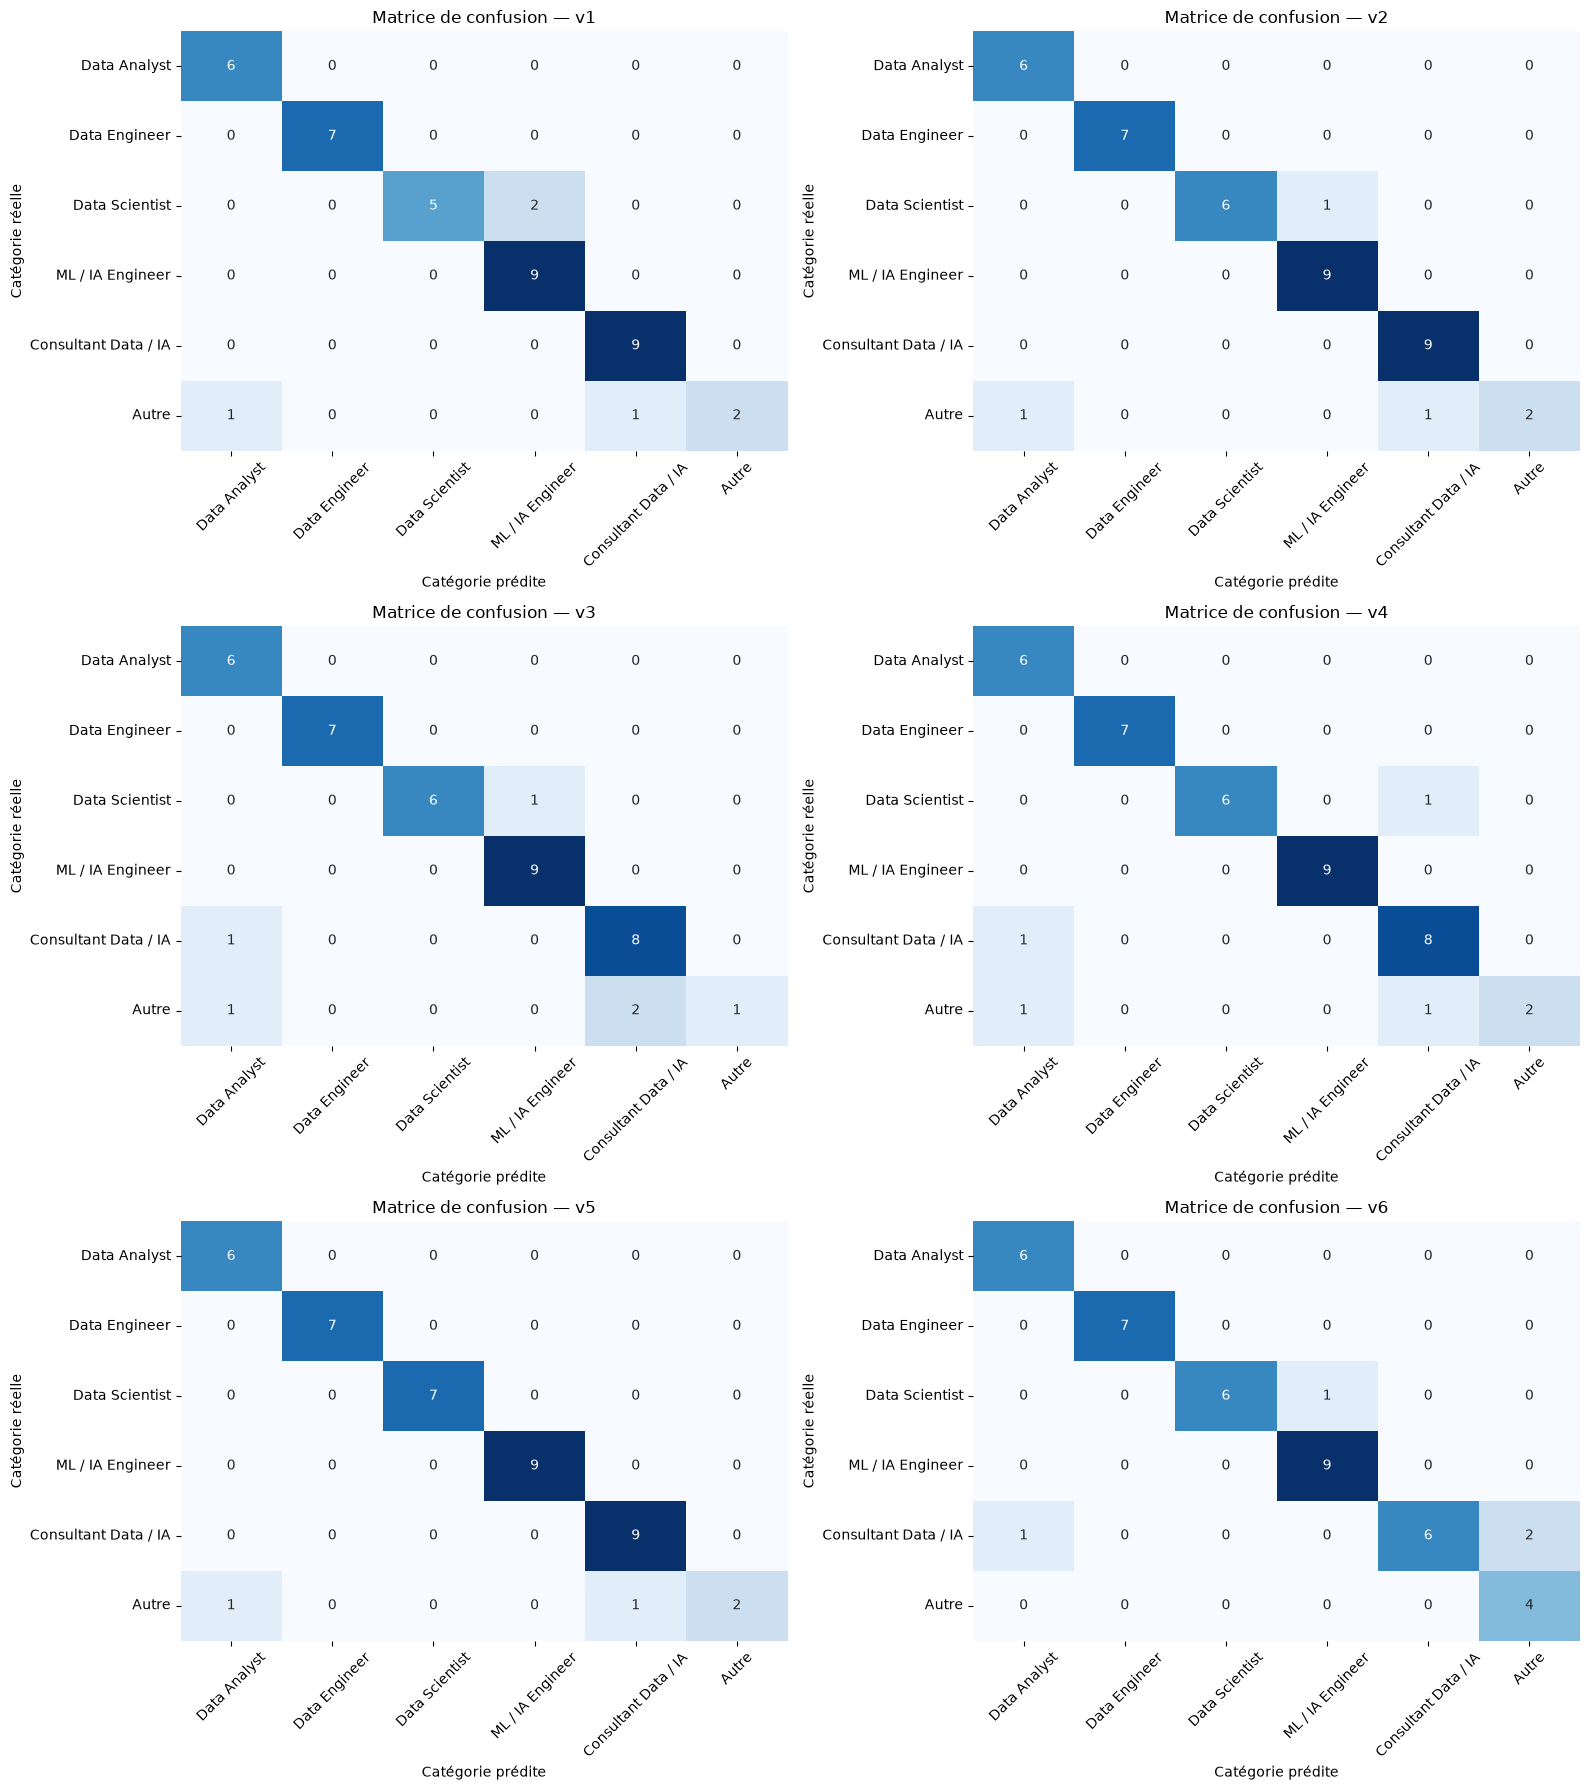


ERREURS — v1 : 4 offres


,entreprise,poste,Job_cat,cat_regex,pred_v1
2,Direct assurance,Data Scientist H/F,Data Scientist,Data Scientist,ML / IA Engineer
13,PSA Retail France SAS,Product Manager-Services Connectés H/F,Autre,Autre,Consultant Data / IA
31,NaN,Alternance - Ingénieur Excellence Opérationnel...,Autre,Data Analyst,Data Analyst
38,Expleo,Data Scientist Llm - ai H/F,Data Scientist,Data Scientist,ML / IA Engineer



ERREURS — v2 : 3 offres


,entreprise,poste,Job_cat,cat_regex,pred_v2
13,PSA Retail France SAS,Product Manager-Services Connectés H/F,Autre,Autre,Consultant Data / IA
31,NaN,Alternance - Ingénieur Excellence Opérationnel...,Autre,Data Analyst,Data Analyst
38,Expleo,Data Scientist Llm - ai H/F,Data Scientist,Data Scientist,ML / IA Engineer



ERREURS — v3 : 5 offres


...


ERREURS — v5 : 2 offres


,entreprise,poste,Job_cat,cat_regex,pred_v5
13,PSA Retail France SAS,Product Manager-Services Connectés H/F,Autre,Autre,Consultant Data / IA
31,NaN,Alternance - Ingénieur Excellence Opérationnel...,Autre,Data Analyst,Data Analyst



ERREURS — v6 : 4 offres


,entreprise,poste,Job_cat,cat_regex,pred_v6
5,Lobellia,Chef de projet / Manager Data - Pilotage equip...,Consultant Data / IA,Data Analyst,Autre
6,Vusion,Chef de Projet IA H/F,Consultant Data / IA,Autre,Autre
27,Collective.work,Data Analyst / Data Consultant (Banque – CIB /...,Consultant Data / IA,Consultant Data / IA,Data Analyst
38,Expleo,Data Scientist Llm - ai H/F,Data Scientist,Data Scientist,ML / IA Engineer


,version,nb_erreurs,taux_erreur
0,v5,2,0.047619
1,v2,3,0.071429
2,v4,4,0.095238
3,v1,4,0.095238
4,v6,4,0.095238
5,v3,5,0.119048


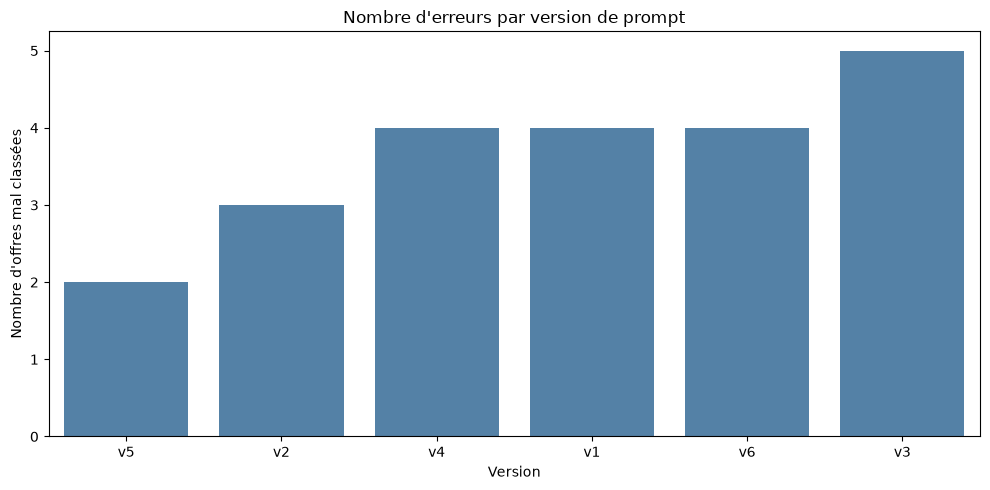


COMPARAISON DES PRÉDICTIONS PAR OFFRE


,entreprise,poste,Job_cat,cat_regex,pred_v1,pred_v2,pred_v3,pred_v4,pred_v5,pred_v6,nb_prompts_en_erreur
31,NaN,Alternance - Ingénieur Excellence Opérationnel...,Autre,Data Analyst,Data Analyst,Data Analyst,Data Analyst,Data Analyst,Data Analyst,Autre,5
13,PSA Retail France SAS,Product Manager-Services Connectés H/F,Autre,Autre,Consultant Data / IA,Consultant Data / IA,Consultant Data / IA,Consultant Data / IA,Consultant Data / IA,Autre,5
38,Expleo,Data Scientist Llm - ai H/F,Data Scientist,Data Scientist,ML / IA Engineer,ML / IA Engineer,ML / IA Engineer,Data Scientist,Data Scientist,ML / IA Engineer,4
27,Collective.work,Data Analyst / Data Consultant (Banque – CIB /...,Consultant Data / IA,Consultant Data / IA,Consultant Data / IA,Consultant Data / IA,Data Analyst,Data Analyst,Consultant Data / IA,Data Analyst,3
6,Vusion,Chef de Projet IA H/F,Consultant Data / IA,Autre,Consultant Data / IA,Consultant Data / IA,Consultant Data / IA,Consultant Data / IA,Consultant Data / IA,Autre,1
2,Direct assurance,Data Scientist H/F,Data Scientist,Data Scientist,ML / IA Engineer,Data Scientist,Data Scientist,Data Scientist,Data Scientist,Data Scientist,1
5,Lobellia,Chef de projet / Manager Data - Pilotage equip...,Consultant Data / IA,Data Analyst,Consultant Data / IA,Consultant Data / IA,Consultant Data / IA,Consultant Data / IA,Consultant Data / IA,Autre,1
4,Coface,Product Owner / API Developer Experience Tools,Autre,Autre,Autre,Autre,Consultant Data / IA,Autre,Autre,Autre,1
0,Groupe Crédit Agricole,ALTERNANCE - Analyste Marketing / Data Scienti...,Data Scientist,Data Scientist,Data Scientist,Data Scientist,Data Scientist,Consultant Data / IA,Data Scientist,Data Scientist,1
1,CGI,Consultant Data Gouvernance - Secteur Public H/F,Consultant Data / IA,Consultant Data / IA,Consultant Data / IA,Consultant Data / IA,Consultant Data / IA,Consultant Data / IA,Consultant Data / IA,Consultant Data / IA,0



CONFUSIONS LES PLUS FRÉQUENTES — v1


,Job_cat,pred_v1,nombre
2,Data Scientist,ML / IA Engineer,2
0,Autre,Consultant Data / IA,1
1,Autre,Data Analyst,1



CONFUSIONS LES PLUS FRÉQUENTES — v2


...


CONFUSIONS LES PLUS FRÉQUENTES — v5


,Job_cat,pred_v5,nombre
0,Autre,Consultant Data / IA,1
1,Autre,Data Analyst,1



CONFUSIONS LES PLUS FRÉQUENTES — v6


,Job_cat,pred_v6,nombre
0,Consultant Data / IA,Autre,2
1,Consultant Data / IA,Data Analyst,1
2,Data Scientist,ML / IA Engineer,1



Analyses exportées avec succès.


In [116]:
# ============================================================
# 4. Comparaison des prompts
# ============================================================

df_metrics = (
    pd.DataFrame(metrics)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

print("\nCOMPARAISON DES PROMPTS")
display(df_metrics)

import math
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ============================================================
# 5. Matrices de confusion de TOUTES les versions
# ============================================================

versions = list(prompts.keys())

n_cols = 2
n_rows = math.ceil(len(versions) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 6 * n_rows),
    squeeze=False
)

for i, version in enumerate(versions):

    ax = axes.flat[i]
    col_pred = f"pred_{version}"

    cm = confusion_matrix(
        resultats["Job_cat"],
        resultats[col_pred],
        labels=categories
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=categories,
        yticklabels=categories,
        ax=ax,
        cbar=False
    )

    ax.set_title(f"Matrice de confusion — {version}")
    ax.set_xlabel("Catégorie prédite")
    ax.set_ylabel("Catégorie réelle")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

# Supprimer les graphiques vides
for j in range(len(versions), len(axes.flat)):
    fig.delaxes(axes.flat[j])

plt.tight_layout()
plt.show()

# ============================================================
# 6. Erreurs de classification pour TOUTES les versions
# ============================================================

erreurs_par_version = {}
resume_erreurs = []

for version in versions:

    col_pred = f"pred_{version}"

    erreurs = resultats.loc[
        resultats["Job_cat"] != resultats[col_pred]
    ].copy()

    erreurs_par_version[version] = erreurs

    resume_erreurs.append({
        "version": version,
        "nb_erreurs": len(erreurs),
        "taux_erreur": len(erreurs) / len(resultats)
    })

    print(f"\n{'=' * 60}")
    print(f"ERREURS — {version} : {len(erreurs)} offres")
    print(f"{'=' * 60}")

    colonnes = [
        "entreprise",
        "poste",
        "Job_cat",
        "cat_regex",
        col_pred
    ]

    display(erreurs[
        [c for c in colonnes if c in erreurs.columns]
    ])

# ============================================================
# 7. Comparaison du nombre d'erreurs
# ============================================================

df_erreurs = (
    pd.DataFrame(resume_erreurs)
    .sort_values("nb_erreurs")
    .reset_index(drop=True)
)

display(df_erreurs)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=df_erreurs,
    x="version",
    y="nb_erreurs",
    color="steelblue"
)

plt.title("Nombre d'erreurs par version de prompt")
plt.xlabel("Version")
plt.ylabel("Nombre d'offres mal classées")
plt.tight_layout()
plt.show()

# ============================================================
# 8. Tableau des prédictions de toutes les versions
# ============================================================

colonnes_comparaison = [
    "entreprise",
    "poste",
    "Job_cat",
    "cat_regex"
] + [f"pred_{v}" for v in versions]

comparaison = resultats[
    [c for c in colonnes_comparaison if c in resultats.columns]
].copy()

# Nombre de prompts qui se trompent pour chaque offre
comparaison["nb_prompts_en_erreur"] = sum(
    comparaison[f"pred_{v}"] != comparaison["Job_cat"]
    for v in versions
)

# Offres les plus difficiles en premier
comparaison = comparaison.sort_values(
    "nb_prompts_en_erreur",
    ascending=False
)

print("\nCOMPARAISON DES PRÉDICTIONS PAR OFFRE")
display(comparaison)

# ============================================================
# 9. Confusions les plus fréquentes par version
# ============================================================

for version, erreurs in erreurs_par_version.items():

    col_pred = f"pred_{version}"

    confusions = (
        erreurs.groupby(["Job_cat", col_pred])
        .size()
        .reset_index(name="nombre")
        .sort_values("nombre", ascending=False)
    )

    print(f"\nCONFUSIONS LES PLUS FRÉQUENTES — {version}")
    display(confusions)

# ============================================================
# 10. Export des analyses
# ============================================================

output_dir = Path("src/extraction/data_llm/evaluation_prompts")
output_dir.mkdir(parents=True, exist_ok=True)

with pd.ExcelWriter(
    output_dir / "analyse_erreurs_prompts.xlsx"
) as writer:

    df_metrics.to_excel(
        writer,
        sheet_name="metrics",
        index=False
    )

    comparaison.to_excel(
        writer,
        sheet_name="comparaison",
        index=False
    )

    for version, erreurs in erreurs_par_version.items():
        erreurs.to_excel(
            writer,
            sheet_name=f"erreurs_{version}"[:31],
            index=False
        )

fig.savefig(
    output_dir / "matrices_confusion.png",
    dpi=200,
    bbox_inches="tight"
)

print("\nAnalyses exportées avec succès.")
